# Cálculo de scores para verificación de locutor

En las etapas anteriores del proyecto se extrajeron embeddings de voz utilizando dos modelos distintos:

- **x-vector**
- **ECAPA-TDNN**

Cada embedding representa numéricamente las características de voz de un audio. Es decir, cada segmento de voz fue transformado en un vector de números que resume información relevante sobre la identidad del locutor.

En esta etapa utilizaremos esos embeddings para calcular **scores de similitud** entre pares de audios. Estos pares están definidos por los trials del protocolo experimental.

El objetivo principal es comparar un embedding de **enrollment** contra un embedding de **test** y obtener un valor numérico que indique qué tan parecidos son ambos vectores.

De manera general, cada comparación tendrá la forma:

$$
\text{score} = s(\mathbf{x}_{enrollment}, \mathbf{x}_{test})
$$

donde:

- $\mathbf{x}_{enrollment}$ es el embedding asociado al audio o locutor de referencia.
- $\mathbf{x}_{test}$ es el embedding asociado al audio de prueba.
- $s(\cdot, \cdot)$ es una función de similitud.

En este notebook utilizaremos como métrica principal la **similitud coseno**, una medida ampliamente usada para comparar embeddings en sistemas de verificación de locutor.

### ¿Qué es un score?

En verificación de locutor, un **score** es un valor numérico que mide qué tan compatible es un audio de prueba con una identidad de referencia.

En nuestro caso, la identidad de referencia está representada por un embedding de enrollment, mientras que el audio de prueba está representado por un embedding de test.

Un score alto indica que los embeddings son similares, por lo que el sistema encuentra evidencia a favor de que ambos audios podrían pertenecer al mismo locutor.

Un score bajo indica que los embeddings son diferentes, por lo que el sistema encuentra evidencia en contra de que ambos audios pertenezcan al mismo locutor.

En esta etapa todavía no tomaremos una decisión final de aceptación o rechazo. Primero calcularemos los scores. La decisión dependerá posteriormente de un umbral, que será analizado en la etapa de evaluación.

### Similitud coseno

La similitud coseno compara dos vectores midiendo el coseno del ángulo entre ellos.

Matemáticamente, para dos vectores $\mathbf{x}$ y $\mathbf{y}$, se define como:

$$
\cos(\mathbf{x}, \mathbf{y}) =
\frac{\mathbf{x} \cdot \mathbf{y}}
{\|\mathbf{x}\|_2 \|\mathbf{y}\|_2}
$$

donde:

- $\mathbf{x} \cdot \mathbf{y}$ es el producto punto entre ambos vectores.
- $\|\mathbf{x}\|_2$ es la norma euclidiana del vector $\mathbf{x}$.
- $\|\mathbf{y}\|_2$ es la norma euclidiana del vector $\mathbf{y}$.


La similitud coseno se enfoca principalmente en la dirección de los vectores, no en su magnitud. Por esta razón es útil para comparar embeddings, ya que nos interesa saber si dos representaciones apuntan hacia regiones similares del espacio vectorial.

In [1]:
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

In [2]:
# Directorio raíz del proyecto.
# Si el notebook está en la raíz del proyecto, esta ruta puede quedarse así.
PROJECT_DIR = Path(".")

# Carpeta donde se guardaron los embeddings
EMBEDDINGS_DIR = PROJECT_DIR / "outputs" / "embeddings"

# Carpeta específica para embeddings ECAPA-TDNN
ECAPA_DIR = EMBEDDINGS_DIR / "ecapa_tdnn"

# Carpeta donde guardaremos los scores generados en esta etapa
SCORES_DIR = PROJECT_DIR / "outputs" / "scores"

# Crear carpeta de scores si no existe
SCORES_DIR.mkdir(parents=True, exist_ok=True)

print("Directorio del proyecto:", PROJECT_DIR.resolve())
print("Directorio de embeddings:", EMBEDDINGS_DIR.resolve())
print("Directorio ECAPA-TDNN:", ECAPA_DIR.resolve())
print("Directorio de scores:", SCORES_DIR.resolve())

Directorio del proyecto: C:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS
Directorio de embeddings: C:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\embeddings
Directorio ECAPA-TDNN: C:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\embeddings\ecapa_tdnn
Directorio de scores: C:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\scores


In [6]:
# Archivos de entrada para x-vector

xvector_trials_ready_path = EMBEDDINGS_DIR / "xvector_trials_ready.pkl"
xvector_trials_metadata_path = EMBEDDINGS_DIR / "xvector_trials_scoring_metadata.csv"

xvector_enrollment_matrix_path = EMBEDDINGS_DIR / "xvector_enrollment_matrix.npy"
xvector_test_matrix_path = EMBEDDINGS_DIR / "xvector_test_matrix.npy"

xvector_enrollment_metadata_path = EMBEDDINGS_DIR / "xvector_enrollment_metadata.csv"
xvector_test_metadata_path = EMBEDDINGS_DIR / "xvector_test_metadata.csv"



# Archivos de entrada para ECAPA-TDNN

ecapa_enrollment_embeddings_path = ECAPA_DIR / "ecapa_enrollment_embeddings.pkl"
ecapa_test_embeddings_path = ECAPA_DIR / "ecapa_test_embeddings.pkl"

ecapa_enrollment_matrix_path = ECAPA_DIR / "ecapa_enrollment_embeddings.npy"
ecapa_test_matrix_path = ECAPA_DIR / "ecapa_test_embeddings.npy"

ecapa_enrollment_index_path = ECAPA_DIR / "ecapa_enrollment_index.csv"
ecapa_test_index_path = ECAPA_DIR / "ecapa_test_index.csv"



# Archivo de trials del protocolo experimental


trials_path = PROJECT_DIR / "trials.csv"

In [4]:
# Función auxiliar para verificar archivos

def check_file_exists(path):
    """
    Verifica si un archivo existe.

    Parámetros
    ----------
    path : pathlib.Path
        Ruta del archivo que se desea verificar.

    Regresa
    -------
    bool
        True si el archivo existe, False en caso contrario.
    """
    exists = path.exists()
    
    status = "OK" if exists else "NO ENCONTRADO"
    print(f"{status:15s} | {path}")
    
    return exists

In [7]:
# Verificar archivos necesarios


input_files = [
    xvector_trials_ready_path,
    xvector_trials_metadata_path,
    xvector_enrollment_matrix_path,
    xvector_test_matrix_path,
    xvector_enrollment_metadata_path,
    xvector_test_metadata_path,
    ecapa_enrollment_embeddings_path,
    ecapa_test_embeddings_path,
    ecapa_enrollment_matrix_path,
    ecapa_test_matrix_path,
    ecapa_enrollment_index_path,
    ecapa_test_index_path,
    trials_path,
]

all_files_exist = True

for file_path in input_files:
    exists = check_file_exists(file_path)
    all_files_exist = all_files_exist and exists

print("\n¿Todos los archivos fueron encontrados?", all_files_exist)

OK              | outputs\embeddings\xvector_trials_ready.pkl
OK              | outputs\embeddings\xvector_trials_scoring_metadata.csv
OK              | outputs\embeddings\xvector_enrollment_matrix.npy
OK              | outputs\embeddings\xvector_test_matrix.npy
OK              | outputs\embeddings\xvector_enrollment_metadata.csv
OK              | outputs\embeddings\xvector_test_metadata.csv
OK              | outputs\embeddings\ecapa_tdnn\ecapa_enrollment_embeddings.pkl
OK              | outputs\embeddings\ecapa_tdnn\ecapa_test_embeddings.pkl
OK              | outputs\embeddings\ecapa_tdnn\ecapa_enrollment_embeddings.npy
OK              | outputs\embeddings\ecapa_tdnn\ecapa_test_embeddings.npy
OK              | outputs\embeddings\ecapa_tdnn\ecapa_enrollment_index.csv
OK              | outputs\embeddings\ecapa_tdnn\ecapa_test_index.csv
OK              | trials.csv

¿Todos los archivos fueron encontrados? True


## Carga de archivos para scoring

En esta sección cargaremos los archivos generados en las etapas anteriores.

Para el modelo **x-vector**, ya contamos con una tabla llamada `xvector_trials_ready.pkl`, que contiene los trials junto con sus embeddings de enrollment y test.

Para el modelo **ECAPA-TDNN**, tenemos los embeddings guardados en diccionarios separados:

- Un diccionario para embeddings de enrollment.
- Un diccionario para embeddings de test.

Por esta razón, para ECAPA-TDNN construiremos posteriormente una tabla equivalente a la de x-vector, agregando a cada trial el embedding correspondiente de enrollment y el embedding correspondiente de test.

También cargaremos el archivo `trials.csv`, que contiene el protocolo experimental definido previamente.

In [8]:
# Funciones auxiliares de carga

def load_pickle(path):
    """
    Carga un archivo pickle.

    Parámetros
    ----------
    path : pathlib.Path
        Ruta del archivo .pkl.

    Regresa
    -------
    object
        Objeto de Python almacenado en el archivo pickle.
    """
    with open(path, "rb") as f:
        obj = pickle.load(f)
    return obj


def load_dataframe_pickle(path):
    """
    Carga un DataFrame guardado en formato pickle.

    Parámetros
    ----------
    path : pathlib.Path
        Ruta del archivo .pkl.

    Regresa
    -------
    pandas.DataFrame
        DataFrame cargado desde el archivo.
    """
    return pd.read_pickle(path)


def summarize_dataframe(df, name):
    """
    Imprime un resumen básico de un DataFrame.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame que se desea resumir.

    name : str
        Nombre descriptivo del DataFrame.
    """
    print("=" * 70)
    print(f"Resumen de: {name}")
    print("=" * 70)
    print("Dimensiones:", df.shape)
    print("\nColumnas:")
    print(list(df.columns))
    print("\nPrimeras filas:")
    display(df.head())

### Carga de archivos x-vector

En la fase de extracción de embeddings con x-vector se construyó una tabla llamada `df_trials_ready`.

Esta tabla contiene la información del trial y dos columnas especiales:

- `enrollment_embedding`: embedding de referencia.
- `test_embedding`: embedding del audio de prueba.

Esto permite calcular directamente el score de similitud para cada fila de la tabla.

In [9]:
# Cargar trials preparados de x-vector

df_xvector_trials_ready = load_dataframe_pickle(xvector_trials_ready_path)
df_xvector_trials_metadata = pd.read_csv(xvector_trials_metadata_path)

summarize_dataframe(
    df_xvector_trials_ready,
    "df_xvector_trials_ready"
)

summarize_dataframe(
    df_xvector_trials_metadata,
    "df_xvector_trials_metadata"
)

Resumen de: df_xvector_trials_ready
Dimensiones: (26330, 15)

Columnas:
['trial_id', 'enrollment_speaker_id', 'enrollment_audio_id', 'enrollment_audio_path', 'test_speaker_id', 'test_audio_id', 'test_audio_path', 'gender_enrollment', 'gender_test', 'trial_type', 'same_speaker', 'same_gender', 'label', 'enrollment_embedding', 'test_embedding']

Primeras filas:


,trial_id,enrollment_speaker_id,enrollment_audio_id,enrollment_audio_path,test_speaker_id,test_audio_id,test_audio_path,gender_enrollment,gender_test,trial_type,same_speaker,same_gender,label,enrollment_embedding,test_embedding
0,trial_000000,M_35,CMPL_M_35_15ALX_00068,CMPL_M_35_15ALX_00068.flac,M_03,CMPL_M_03_08MAB_00863,CMPL_M_03_08MAB_00863.flac,male,male,impostor,False,True,0,"[-17.123379, 1.2422428, 20.933079, 7.462077, 8...","[-19.962603, 7.5459538, 9.299501, 9.304432, 1...."
1,trial_000001,M_01,CMPL_M_01_13ANG_01532,CMPL_M_01_13ANG_01532.flac,M_01,CMPL_M_01_03ANG_00390,CMPL_M_01_03ANG_00390.flac,male,male,genuine,True,True,1,"[-23.182505, 14.880242, 7.979873, 6.211931, -0...","[-21.204844, 11.698339, 8.127685, 7.8365083, 0..."
2,trial_000002,M_41,CMPL_M_41_14MAB_00025,CMPL_M_41_14MAB_00025.flac,M_41,CMPL_M_41_14MAB_00005,CMPL_M_41_14MAB_00005.flac,male,male,genuine,True,True,1,"[-22.429392, 4.3239303, 9.547012, 12.241033, 8...","[-19.622282, 0.06936355, 0.4334539, 10.119689,..."
3,trial_000003,M_04,CMPL_M_04_02ANG_00433,CMPL_M_04_02ANG_00433.flac,M_04,CMPL_M_04_02ALX_00160,CMPL_M_04_02ALX_00160.flac,male,male,genuine,True,True,1,"[-18.34024, -0.30849364, 4.3463163, 2.474576, ...","[-21.271435, 0.72722214, 8.219761, 0.051693197..."
4,trial_000004,M_26,CMPL_M_26_03ALX_00015,CMPL_M_26_03ALX_00015.flac,M_35,CMPL_M_35_05MAB_00044,CMPL_M_35_05MAB_00044.flac,male,male,impostor,False,True,0,"[-20.541666, -1.3960748, 14.013562, 4.410718, ...","[-19.977213, 9.640423, 13.888627, 4.9822035, 1..."


Resumen de: df_xvector_trials_metadata
Dimensiones: (26330, 11)

Columnas:
['trial_id', 'enrollment_speaker_id', 'enrollment_audio_id', 'test_speaker_id', 'test_audio_id', 'gender_enrollment', 'gender_test', 'trial_type', 'same_speaker', 'same_gender', 'label']

Primeras filas:


,trial_id,enrollment_speaker_id,enrollment_audio_id,test_speaker_id,test_audio_id,gender_enrollment,gender_test,trial_type,same_speaker,same_gender,label
0,trial_000000,M_35,CMPL_M_35_15ALX_00068,M_03,CMPL_M_03_08MAB_00863,male,male,impostor,False,True,0
1,trial_000001,M_01,CMPL_M_01_13ANG_01532,M_01,CMPL_M_01_03ANG_00390,male,male,genuine,True,True,1
2,trial_000002,M_41,CMPL_M_41_14MAB_00025,M_41,CMPL_M_41_14MAB_00005,male,male,genuine,True,True,1
3,trial_000003,M_04,CMPL_M_04_02ANG_00433,M_04,CMPL_M_04_02ALX_00160,male,male,genuine,True,True,1
4,trial_000004,M_26,CMPL_M_26_03ALX_00015,M_35,CMPL_M_35_05MAB_00044,male,male,impostor,False,True,0


### Carga de archivos ECAPA-TDNN

En la fase de extracción de embeddings con ECAPA-TDNN los embeddings se guardaron como diccionarios:

$$
\text{audio\_id} \rightarrow \text{embedding}
$$

Esto significa que cada llave del diccionario corresponde al identificador de un audio y cada valor corresponde al embedding calculado para ese audio.

Para scoring necesitamos construir una tabla donde cada trial tenga:

- El embedding de enrollment.
- El embedding de test.

Esta tabla será equivalente a `df_xvector_trials_ready`, pero usando embeddings de ECAPA-TDNN.

In [ ]:
# Cargar diccionarios de embeddings ECAPA-TDNN

ecapa_enrollment_embeddings = load_pickle(ecapa_enrollment_embeddings_path)
ecapa_test_embeddings = load_pickle(ecapa_test_embeddings_path)

print("Tipo objeto enrollment ECAPA:", type(ecapa_enrollment_embeddings))
print("Tipo objeto test ECAPA:", type(ecapa_test_embeddings))

print("Número de embeddings enrollment ECAPA:", len(ecapa_enrollment_embeddings))
print("Número de embeddings test ECAPA:", len(ecapa_test_embeddings))

Tipo objeto enrollment ECAPA: <class 'dict'>
Tipo objeto test ECAPA: <class 'dict'>
Número de embeddings enrollment ECAPA: 87
Número de embeddings test ECAPA: 13165


In [14]:
# Cargar matrices e índices ECAPA-TDNN


ecapa_enrollment_matrix = np.load(ecapa_enrollment_matrix_path)
ecapa_test_matrix = np.load(ecapa_test_matrix_path)

df_ecapa_enrollment_index = pd.read_csv(ecapa_enrollment_index_path)
df_ecapa_test_index = pd.read_csv(ecapa_test_index_path)

print("Shape matriz enrollment ECAPA:", ecapa_enrollment_matrix.shape)
print("Shape matriz test ECAPA:", ecapa_test_matrix.shape)

summarize_dataframe(
    df_ecapa_enrollment_index,
    "df_ecapa_enrollment_index"
)

summarize_dataframe(
    df_ecapa_test_index,
    "df_ecapa_test_index"
)

Shape matriz enrollment ECAPA: (87, 192)
Shape matriz test ECAPA: (13165, 192)
Resumen de: df_ecapa_enrollment_index
Dimensiones: (87, 5)

Columnas:
['row_index', 'audio_id', 'speaker_id', 'embedding_model', 'embedding_dim']

Primeras filas:


,row_index,audio_id,speaker_id,embedding_model,embedding_dim
0,0,CMPL_F_01_12MAB_00651,F_01,ecapa_tdnn,192
1,1,CMPL_F_02_02MAB_00241,F_02,ecapa_tdnn,192
2,2,CMPL_F_03_09MAB_00142,F_03,ecapa_tdnn,192
3,3,CMPL_F_04_12ANG_00215,F_04,ecapa_tdnn,192
4,4,CMPL_F_05_01CAR_00021,F_05,ecapa_tdnn,192


Resumen de: df_ecapa_test_index
Dimensiones: (13165, 5)

Columnas:
['row_index', 'audio_id', 'speaker_id', 'embedding_model', 'embedding_dim']

Primeras filas:


,row_index,audio_id,speaker_id,embedding_model,embedding_dim
0,0,CMPL_F_01_03MAB_00001,F_01,ecapa_tdnn,192
1,1,CMPL_F_01_03MAB_00002,F_01,ecapa_tdnn,192
2,2,CMPL_F_01_03MAB_00003,F_01,ecapa_tdnn,192
3,3,CMPL_F_01_03MAB_00004,F_01,ecapa_tdnn,192
4,4,CMPL_F_01_03MAB_00005,F_01,ecapa_tdnn,192


In [16]:
# Cargar archivo general de trials

df_trials = pd.read_csv(trials_path)

summarize_dataframe(
    df_trials,
    "df_trials"
)

Resumen de: df_trials
Dimensiones: (26330, 13)

Columnas:
['trial_id', 'enrollment_speaker_id', 'enrollment_audio_id', 'enrollment_audio_path', 'test_speaker_id', 'test_audio_id', 'test_audio_path', 'gender_enrollment', 'gender_test', 'trial_type', 'same_speaker', 'same_gender', 'label']

Primeras filas:


,trial_id,enrollment_speaker_id,enrollment_audio_id,enrollment_audio_path,test_speaker_id,test_audio_id,test_audio_path,gender_enrollment,gender_test,trial_type,same_speaker,same_gender,label
0,trial_000000,M_35,CMPL_M_35_15ALX_00068,CMPL_M_35_15ALX_00068.flac,M_03,CMPL_M_03_08MAB_00863,CMPL_M_03_08MAB_00863.flac,male,male,impostor,False,True,0
1,trial_000001,M_01,CMPL_M_01_13ANG_01532,CMPL_M_01_13ANG_01532.flac,M_01,CMPL_M_01_03ANG_00390,CMPL_M_01_03ANG_00390.flac,male,male,genuine,True,True,1
2,trial_000002,M_41,CMPL_M_41_14MAB_00025,CMPL_M_41_14MAB_00025.flac,M_41,CMPL_M_41_14MAB_00005,CMPL_M_41_14MAB_00005.flac,male,male,genuine,True,True,1
3,trial_000003,M_04,CMPL_M_04_02ANG_00433,CMPL_M_04_02ANG_00433.flac,M_04,CMPL_M_04_02ALX_00160,CMPL_M_04_02ALX_00160.flac,male,male,genuine,True,True,1
4,trial_000004,M_26,CMPL_M_26_03ALX_00015,CMPL_M_26_03ALX_00015.flac,M_35,CMPL_M_35_05MAB_00044,CMPL_M_35_05MAB_00044.flac,male,male,impostor,False,True,0


## Normalización L2 de embeddings

Antes de calcular la similitud entre embeddings, es común aplicar una normalización L2.

La normalización L2 transforma un vector para que su norma euclidiana sea igual a 1.

Si tenemos un embedding $\mathbf{x}$, su versión normalizada se define como:

$$
\hat{\mathbf{x}} = \frac{\mathbf{x}}{\|\mathbf{x}\|_2}
$$

donde:

$$
\|\mathbf{x}\|_2 = \sqrt{x_1^2 + x_2^2 + \cdots + x_d^2}
$$

Después de esta transformación, el vector conserva su dirección, pero su magnitud queda normalizada.

Esto es importante porque, al comparar embeddings de locutor, normalmente queremos comparar su orientación en el espacio vectorial más que su tamaño absoluto.

In [19]:
# Función de normalización L2

def l2_normalize_vector(vector, eps=1e-12):
    """
    Normaliza un vector usando norma L2.

    La normalización L2 divide el vector entre su norma euclidiana.
    Esto produce un vector con norma aproximadamente igual a 1.

    Parámetros
    ----------
    vector : array-like
        Vector que se desea normalizar.

    eps : float, default=1e-12
        Constante pequeña para evitar división entre cero.

    Regresa
    -------
    numpy.ndarray
        Vector normalizado.
    """
    vector = np.asarray(vector, dtype=np.float32).reshape(-1)
    norm = np.linalg.norm(vector, ord=2)

    if norm < eps:
        return vector

    return vector / norm

## 21. Cálculo de similitud coseno

Una vez normalizados los embeddings, la similitud coseno puede calcularse de forma muy simple mediante el producto punto.

Si $\hat{\mathbf{x}}$ y $\hat{\mathbf{y}}$ son dos embeddings normalizados, entonces:

$$
\cos(\hat{\mathbf{x}}, \hat{\mathbf{y}}) =
\hat{\mathbf{x}} \cdot \hat{\mathbf{y}}
$$

Esto ocurre porque ambos vectores tienen norma igual a 1.

En la práctica, calcularemos el score de cada trial comparando:

$$
\text{embedding de enrollment}
\quad \text{vs} \quad
\text{embedding de test}
$$

El resultado será una nueva columna con el score coseno.

In [20]:
# Función de similitud coseno para dos embeddings

def cosine_score(embedding_a, embedding_b, normalize=True):
    """
    Calcula la similitud coseno entre dos embeddings.

    Parámetros
    ----------
    embedding_a : array-like
        Primer embedding.

    embedding_b : array-like
        Segundo embedding.

    normalize : bool, default=True
        Si True, aplica normalización L2 antes de calcular el producto punto.

    Regresa
    -------
    float
        Score de similitud coseno.
    """
    vector_a = np.asarray(embedding_a, dtype=np.float32).reshape(-1)
    vector_b = np.asarray(embedding_b, dtype=np.float32).reshape(-1)

    if vector_a.shape != vector_b.shape:
        raise ValueError(
            f"Los embeddings tienen dimensiones diferentes: "
            f"{vector_a.shape} vs {vector_b.shape}"
        )

    if normalize:
        vector_a = l2_normalize_vector(vector_a)
        vector_b = l2_normalize_vector(vector_b)

    score = np.dot(vector_a, vector_b)

    return float(score)

### Función general para calcular scores en un DataFrame

Ahora construiremos una función reutilizable.

La función recibirá un DataFrame donde cada fila representa un trial. Para cada fila tomará:

- El embedding de enrollment.
- El embedding de test.

Después calculará la similitud coseno y guardará el resultado en una nueva columna.

Esta función será útil tanto para x-vector como para ECAPA-TDNN, siempre que el DataFrame tenga las columnas de embeddings correspondientes.

In [22]:
# Función general para calcular scores en un DataFrame

def compute_cosine_scores_for_trials(
    df,
    enrollment_embedding_col="enrollment_embedding",
    test_embedding_col="test_embedding",
    score_col="cosine_score",
    normalize=True,
    verbose=True
):
    """
    Calcula scores coseno para cada trial de un DataFrame.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame donde cada fila representa un trial.

    enrollment_embedding_col : str
        Nombre de la columna que contiene el embedding de enrollment.

    test_embedding_col : str
        Nombre de la columna que contiene el embedding de test.

    score_col : str
        Nombre de la nueva columna donde se guardará el score.

    normalize : bool, default=True
        Si True, aplica normalización L2 antes de calcular el score.

    verbose : bool, default=True
        Si True, imprime información del proceso.

    Regresa
    -------
    pandas.DataFrame
        Copia del DataFrame original con una nueva columna de scores.
    """
    df_scores = df.copy()

    required_columns = [
        enrollment_embedding_col,
        test_embedding_col
    ]

    missing_columns = [
        col for col in required_columns
        if col not in df_scores.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Faltan columnas necesarias para calcular scores: {missing_columns}"
        )

    if verbose:
        print("Calculando scores coseno...")
        print("Número de trials:", len(df_scores))
        print("Columna enrollment:", enrollment_embedding_col)
        print("Columna test:", test_embedding_col)
        print("Columna score:", score_col)
        print("Normalización L2:", normalize)

    scores = []

    for _, row in df_scores.iterrows():
        score = cosine_score(
            row[enrollment_embedding_col],
            row[test_embedding_col],
            normalize=normalize
        )
        scores.append(score)

    df_scores[score_col] = scores

    if verbose:
        print("Cálculo de scores completado.")
        print("Resumen de scores:")
        print(df_scores[score_col].describe())

    return df_scores

### Cálculo completo de scores para x-vector

En esta sección calcularemos la similitud coseno para todos los trials construidos con embeddings x-vector.

Cada fila del DataFrame representa una comparación entre:

- Un embedding de enrollment.
- Un embedding de test.

El resultado será una nueva columna llamada `xvector_cosine_score`.

Esta columna será la salida principal del scoring para el modelo x-vector y será usada posteriormente para calcular métricas de evaluación como EER, ROC, DET Curve, FAR y FRR.

In [28]:
# Cálculo completo de scores para x-vector

df_xvector_scores = compute_cosine_scores_for_trials(
    df=df_xvector_trials_ready,
    enrollment_embedding_col="enrollment_embedding",
    test_embedding_col="test_embedding",
    score_col="xvector_cosine_score",
    normalize=True,
    verbose=False
)

print("\nDimensiones del DataFrame con scores x-vector:")
print(df_xvector_scores.shape)


Dimensiones del DataFrame con scores x-vector:
(26330, 16)


## Visualización inicial de scores x-vector

A continuación construiremos un histograma para comparar visualmente la distribución de scores genuinos e impostores.

Esta gráfica no sustituye a métricas formales como EER o ROC, pero ayuda a observar si existe separación entre ambas clases.

Una buena separación visual indicaría que el modelo asigna scores más altos a comparaciones del mismo locutor y scores más bajos a comparaciones de locutores distintos.

In [ ]:
# Crear una columna interpretable para el tipo de trial

df_xvector_scores["trial_class"] = np.where(
    df_xvector_scores["same_speaker"] == True,
    "genuine",
    "impostor"
)

,trial_id,same_speaker,label,trial_class,xvector_cosine_score
0,trial_000000,False,0,impostor,0.924184
1,trial_000001,True,1,genuine,0.922048
2,trial_000002,True,1,genuine,0.933037
3,trial_000003,True,1,genuine,0.947141
4,trial_000004,False,0,impostor,0.905483


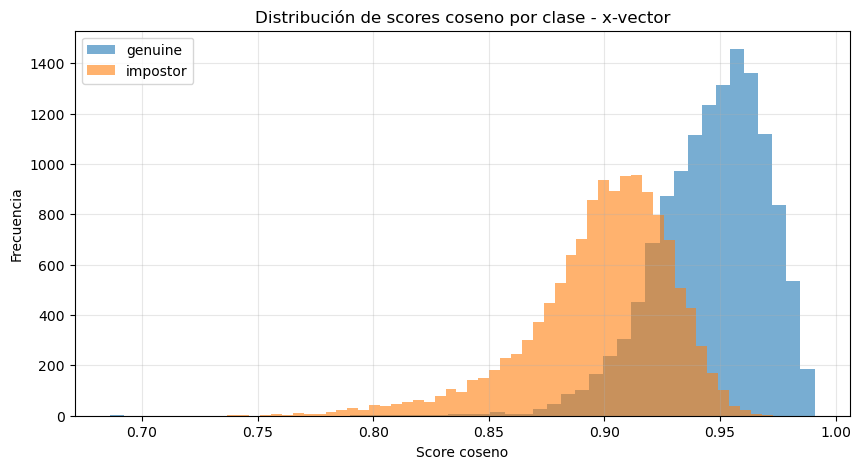

In [ ]:
# Histograma de scores x-vector por clase interpretable

plt.figure(figsize=(10, 5))

for trial_class in ["genuine", "impostor"]:
    subset = df_xvector_scores[df_xvector_scores["trial_class"] == trial_class]
    
    plt.hist(
        subset["xvector_cosine_score"],
        bins=50,
        alpha=0.6,
        label=trial_class
    )

plt.title("Distribución de scores coseno por clase - x-vector")
plt.xlabel("Score coseno")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Guardado de scores x-vector

Una vez calculados y validados los scores, guardaremos los resultados en la carpeta:

```text
outputs/scores/
```

Guardaremos dos versiones:

Una versión .pkl, que conserva el DataFrame completo, incluyendo columnas con embeddings.
Una versión .csv, más ligera, que conserva solamente metadatos y scores.


La versión .csv será útil para análisis rápidos y para la etapa de evaluación.
La versión .pkl será útil si necesitamos recuperar objetos completos de Python sin recalcular el scoring.

In [38]:
# Definir rutas de salida para scores x-vector

xvector_scores_pkl_path = SCORES_DIR / "xvector_cosine_scores.pkl"
xvector_scores_csv_path = SCORES_DIR / "xvector_cosine_scores.csv"

In [40]:
# Columnas ligeras para guardar en CSV

xvector_score_columns = [
    "trial_id",
    "enrollment_speaker_id",
    "enrollment_audio_id",
    "test_speaker_id",
    "test_audio_id",
    "trial_type",
    "same_speaker",
    "same_gender",
    "label",
    "trial_class",
    "xvector_cosine_score",
]

df_xvector_scores_light = df_xvector_scores[xvector_score_columns].copy()


In [41]:
# Guardar resultados x-vector

df_xvector_scores.to_pickle(xvector_scores_pkl_path)
df_xvector_scores_light.to_csv(xvector_scores_csv_path, index=False)

print("Archivos guardados correctamente:")
print(xvector_scores_pkl_path)
print(xvector_scores_csv_path)

Archivos guardados correctamente:
outputs\scores\xvector_cosine_scores.pkl
outputs\scores\xvector_cosine_scores.csv


## Construcción de trials para ECAPA-TDNN

Para calcular scores con ECAPA-TDNN necesitamos que cada trial tenga dos embeddings:

- `enrollment_embedding`: embedding de referencia.
- `test_embedding`: embedding del audio de prueba.

En la etapa anterior guardamos los embeddings ECAPA-TDNN en diccionarios. Por lo tanto, cada embedding puede recuperarse usando su `audio_id`.

El objetivo de esta sección es construir una tabla equivalente a la de x-vector, pero usando embeddings ECAPA-TDNN.

In [49]:
# Construir DataFrame de trials con embeddings ECAPA-TDNN

df_ecapa_trials_ready = df_trials.copy()

df_ecapa_trials_ready["enrollment_embedding"] = (
    df_ecapa_trials_ready["enrollment_audio_id"]
    .astype(str)
    .map(ecapa_enrollment_embeddings)
)

df_ecapa_trials_ready["test_embedding"] = (
    df_ecapa_trials_ready["test_audio_id"]
    .astype(str)
    .map(ecapa_test_embeddings)
)

print("Dimensiones de df_ecapa_trials_ready:")
print(df_ecapa_trials_ready.shape)


Dimensiones de df_ecapa_trials_ready:
(26330, 15)


## Cálculo de scores para ECAPA-TDNN

En esta sección calcularemos la similitud coseno para todos los trials utilizando embeddings generados con ECAPA-TDNN.

Cada trial compara:

- Un embedding de enrollment.
- Un embedding de test.

El resultado se guardará en una nueva columna llamada `ecapa_cosine_score`.

Estos scores serán utilizados posteriormente para comparar el desempeño de ECAPA-TDNN contra x-vector bajo el mismo protocolo experimental.

In [ ]:
# Cálculo completo de scores para ECAPA-TDNN

df_ecapa_scores = compute_cosine_scores_for_trials(
    df=df_ecapa_trials_ready,
    enrollment_embedding_col="enrollment_embedding",
    test_embedding_col="test_embedding",
    score_col="ecapa_cosine_score",
    normalize=True,
    verbose=False
)

print("\nDimensiones del DataFrame con scores ECAPA-TDNN:")
print(df_ecapa_scores.shape)

Calculando scores coseno...
Número de trials: 26330
Columna enrollment: enrollment_embedding
Columna test: test_embedding
Columna score: ecapa_cosine_score
Normalización L2: True
Cálculo de scores completado.
Resumen de scores:
count    26330.000000
mean         0.376188
std          0.231113
min         -0.233926
25%          0.173985
50%          0.361448
75%          0.580162
max          0.908164
Name: ecapa_cosine_score, dtype: float64

Dimensiones del DataFrame con scores ECAPA-TDNN:
(26330, 16)


In [68]:
# Crear una columna interpretable para el tipo de trial

df_ecapa_scores["trial_class"] = np.where(
    df_ecapa_scores["same_speaker"] == True,
    "genuine",
    "impostor"
)


### Visualización inicial de scores ECAPA-TDNN

Ahora construiremos un histograma para observar la distribución de scores genuinos e impostores.

En un sistema ideal, esperaríamos que la distribución de scores genuinos se concentre hacia valores más altos, mientras que la distribución de scores impostores se concentre hacia valores más bajos.

El grado de traslape entre ambas distribuciones será importante para la etapa posterior de evaluación.

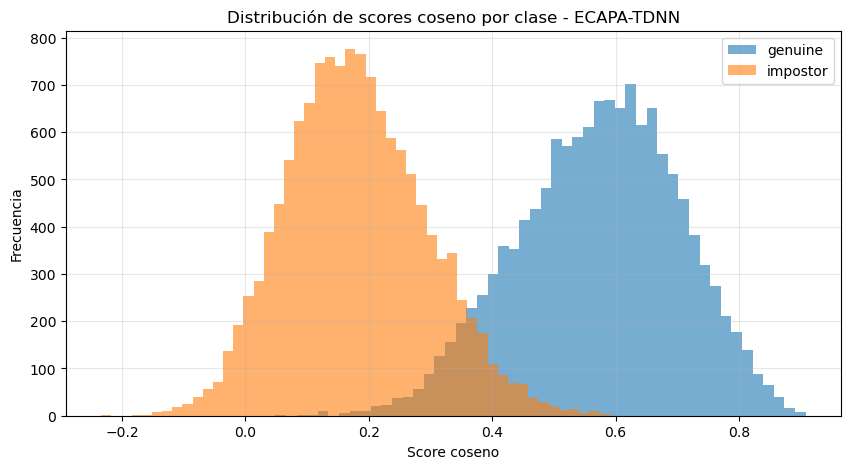

In [69]:
# Histograma de scores ECAPA-TDNN por clase interpretable

plt.figure(figsize=(10, 5))

for trial_class in ["genuine", "impostor"]:
    subset = df_ecapa_scores[df_ecapa_scores["trial_class"] == trial_class]
    
    plt.hist(
        subset["ecapa_cosine_score"],
        bins=50,
        alpha=0.6,
        label=trial_class
    )

plt.title("Distribución de scores coseno por clase - ECAPA-TDNN")
plt.xlabel("Score coseno")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Guardado de scores ECAPA-TDNN

Una vez calculados y validados los scores ECAPA-TDNN, guardaremos los resultados en la carpeta:

```text
outputs/scores/

Guardaremos dos versiones:

Una versión .pkl, que conserva el DataFrame completo, incluyendo las columnas con embeddings.
Una versión .csv, que contiene solamente los metadatos del trial y el score calculado.

```

In [70]:
# Definir rutas de salida para scores ECAPA-TDNN

ecapa_scores_pkl_path = SCORES_DIR / "ecapa_cosine_scores.pkl"
ecapa_scores_csv_path = SCORES_DIR / "ecapa_cosine_scores.csv"

In [71]:
# Columnas ligeras para guardar en CSV

ecapa_score_columns = [
    "trial_id",
    "enrollment_speaker_id",
    "enrollment_audio_id",
    "test_speaker_id",
    "test_audio_id",
    "trial_type",
    "same_speaker",
    "same_gender",
    "label",
    "trial_class",
    "ecapa_cosine_score",
]

df_ecapa_scores_light = df_ecapa_scores[ecapa_score_columns].copy()


In [72]:
# Guardar resultados ECAPA-TDNN

df_ecapa_scores.to_pickle(ecapa_scores_pkl_path)
df_ecapa_scores_light.to_csv(ecapa_scores_csv_path, index=False)

print("Archivos guardados correctamente:")
print(ecapa_scores_pkl_path)
print(ecapa_scores_csv_path)

Archivos guardados correctamente:
outputs\scores\ecapa_cosine_scores.pkl
outputs\scores\ecapa_cosine_scores.csv


## Unificación de scores de x-vector y ECAPA-TDNN

En esta sección unificaremos los scores generados por ambos modelos en una sola tabla.

El objetivo es construir un DataFrame donde cada fila corresponda a un mismo trial del protocolo experimental y contenga:

- El score calculado con x-vector.
- El score calculado con ECAPA-TDNN.
- La etiqueta real del trial, es decir, si corresponde a una comparación genuina o impostora.

Esta tabla será la entrada principal para la siguiente etapa del proyecto, donde calcularemos métricas de evaluación como EER, ROC, DET Curve, FAR y FRR.

### Selección de columnas para la tabla comparativa

Para evitar duplicar columnas durante la unión, tomaremos la información general del trial desde la tabla de x-vector y agregaremos únicamente el score de ECAPA-TDNN desde la tabla correspondiente.

Esto es válido porque previamente verificamos que ambos modelos tienen los mismos `trial_id`.

In [80]:
# Seleccionar columnas para unión

xvector_columns_for_merge = [
    "trial_id",
    "enrollment_speaker_id",
    "enrollment_audio_id",
    "test_speaker_id",
    "test_audio_id",
    "trial_type",
    "same_speaker",
    "same_gender",
    "label",
    "trial_class",
    "xvector_cosine_score",
]

ecapa_columns_for_merge = [
    "trial_id",
    "ecapa_cosine_score",
]

df_xvector_for_merge = df_xvector_scores_light[xvector_columns_for_merge].copy()
df_ecapa_for_merge = df_ecapa_scores_light[ecapa_columns_for_merge].copy()

print("Dimensiones x-vector para unión:", df_xvector_for_merge.shape)
print("Dimensiones ECAPA para unión:", df_ecapa_for_merge.shape)

Dimensiones x-vector para unión: (26330, 11)
Dimensiones ECAPA para unión: (26330, 2)


In [82]:
# Unir scores de ambos modelos usando trial_id

df_combined_scores = df_xvector_for_merge.merge(
    df_ecapa_for_merge,
    on="trial_id",
    how="inner"
)

print("Dimensiones de df_combined_scores:")
print(df_combined_scores.shape)


Dimensiones de df_combined_scores:
(26330, 12)


## Separación inicial entre clases

Una forma sencilla de inspeccionar el comportamiento inicial de los scores es comparar la media de los trials genuinos contra la media de los trials impostores.

Para cada modelo calcularemos:

$$
\Delta = \mu_{\text{genuine}} - \mu_{\text{impostor}}
$$

donde:

- $\mu_{\text{genuine}}$ es la media de los scores genuinos.
- $\mu_{\text{impostor}}$ es la media de los scores impostores.

Un valor positivo indica que, en promedio, el modelo asigna scores mayores a comparaciones del mismo locutor que a comparaciones de locutores distintos.

Este valor no es una métrica final de desempeño, pero funciona como una revisión exploratoria útil.

In [87]:
# Calcular separación inicial de medias por modelo

def mean_separation_by_class(df, score_col, class_col="trial_class"):
    """
    Calcula la diferencia entre la media de scores genuinos
    y la media de scores impostores.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame con scores.

    score_col : str
        Nombre de la columna de score.

    class_col : str
        Nombre de la columna que indica la clase del trial.

    Regresa
    -------
    dict
        Diccionario con medias y diferencia.
    """
    genuine_mean = df.loc[df[class_col] == "genuine", score_col].mean()
    impostor_mean = df.loc[df[class_col] == "impostor", score_col].mean()

    return {
        "score_col": score_col,
        "genuine_mean": genuine_mean,
        "impostor_mean": impostor_mean,
        "mean_difference": genuine_mean - impostor_mean
    }


xvector_mean_sep = mean_separation_by_class(
    df_combined_scores,
    score_col="xvector_cosine_score"
)

ecapa_mean_sep = mean_separation_by_class(
    df_combined_scores,
    score_col="ecapa_cosine_score"
)

df_mean_separation = pd.DataFrame([
    xvector_mean_sep,
    ecapa_mean_sep
])

display(df_mean_separation)

,score_col,genuine_mean,impostor_mean,mean_difference
0,xvector_cosine_score,0.946236,0.898302,0.047934
1,ecapa_cosine_score,0.572404,0.179972,0.392431


### Interpretación de la separación de medias

En general, esperamos que:

$$
\mu_{\text{genuine}} > \mu_{\text{impostor}}
$$

para ambos modelos.

Si esto se cumple, significa que los scores tienen una orientación coherente: valores más altos indican mayor similitud entre voces.

Sin embargo, esta diferencia de medias no es suficiente para concluir qué modelo es mejor. Dos modelos pueden tener medias distintas pero también diferentes niveles de dispersión o traslape entre clases.

Por eso, en la siguiente fase necesitaremos métricas formales como:

- ROC Curve
- DET Curve
- EER
- FAR
- FRR
- umbral óptimo

### Visualización comparativa inicial

Ahora graficaremos las distribuciones de scores genuinos e impostores para ambos modelos.

Estas gráficas permiten comparar visualmente el grado de separación entre clases.

La interpretación general es:

- Mientras más separadas estén las distribuciones de genuinos e impostores, mejor comportamiento inicial tiene el modelo.
- Mientras mayor sea el traslape, más difícil será definir un umbral que separe correctamente ambas clases.

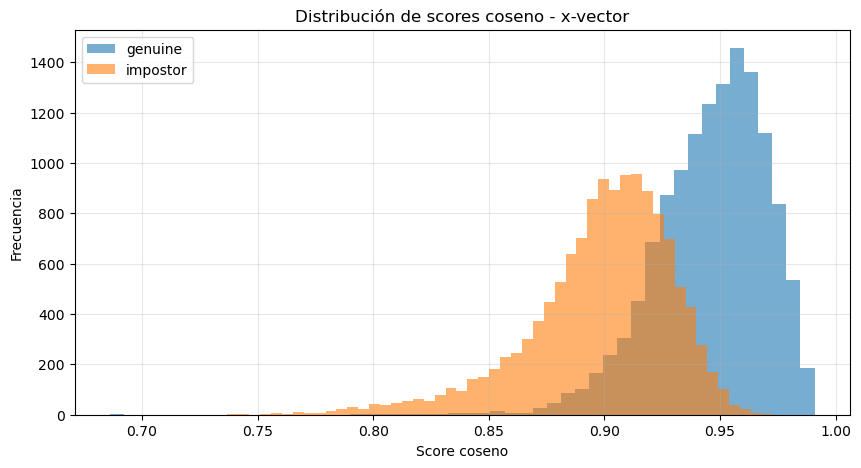

In [88]:
# Histograma comparativo x-vector

plt.figure(figsize=(10, 5))

for trial_class in ["genuine", "impostor"]:
    subset = df_combined_scores[df_combined_scores["trial_class"] == trial_class]

    plt.hist(
        subset["xvector_cosine_score"],
        bins=50,
        alpha=0.6,
        label=trial_class
    )

plt.title("Distribución de scores coseno - x-vector")
plt.xlabel("Score coseno")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

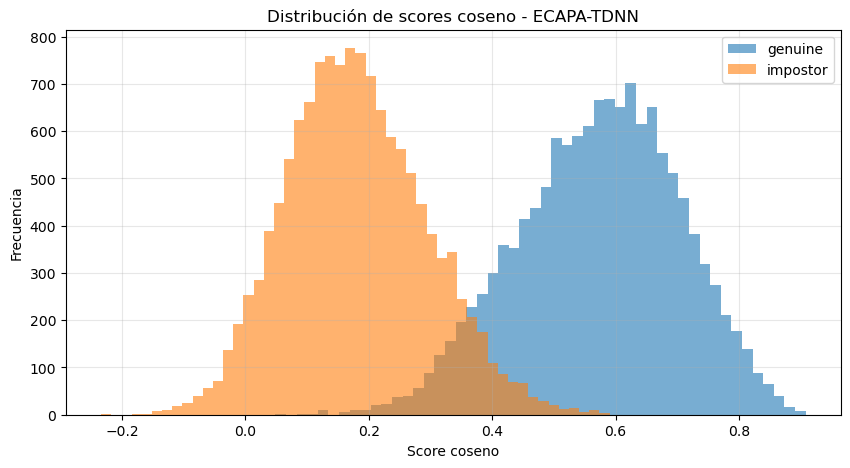

In [89]:
# Histograma comparativo ECAPA-TDNN

plt.figure(figsize=(10, 5))

for trial_class in ["genuine", "impostor"]:
    subset = df_combined_scores[df_combined_scores["trial_class"] == trial_class]

    plt.hist(
        subset["ecapa_cosine_score"],
        bins=50,
        alpha=0.6,
        label=trial_class
    )

plt.title("Distribución de scores coseno - ECAPA-TDNN")
plt.xlabel("Score coseno")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Guardado de la tabla combinada de scores

Finalmente, guardaremos la tabla combinada en la carpeta:

```text
outputs/scores/
```

In [90]:
# Definir rutas de salida para tabla combinada

combined_scores_csv_path = SCORES_DIR / "combined_cosine_scores.csv"
combined_scores_pkl_path = SCORES_DIR / "combined_cosine_scores.pkl"

In [91]:
# Guardar tabla combinada

df_combined_scores.to_csv(combined_scores_csv_path, index=False)
df_combined_scores.to_pickle(combined_scores_pkl_path)

print("Archivos combinados guardados correctamente:")
print(combined_scores_csv_path)
print(combined_scores_pkl_path)

Archivos combinados guardados correctamente:
outputs\scores\combined_cosine_scores.csv
outputs\scores\combined_cosine_scores.pkl


## Tabla de archivos generados

| Archivo | Descripción |
|---|---|
| `xvector_cosine_scores.csv` | Tabla ligera con los scores coseno calculados para x-vector. No contiene embeddings. |
| `xvector_cosine_scores.pkl` | Tabla completa de x-vector, incluyendo metadatos, embeddings y scores. |
| `ecapa_cosine_scores.csv` | Tabla ligera con los scores coseno calculados para ECAPA-TDNN. No contiene embeddings. |
| `ecapa_cosine_scores.pkl` | Tabla completa de ECAPA-TDNN, incluyendo metadatos, embeddings y scores. |
| `combined_cosine_scores.csv` | Tabla comparativa ligera con scores de ambos modelos para cada trial. |
| `combined_cosine_scores.pkl` | Versión pickle de la tabla comparativa combinada. |

## Resumen final de la etapa

En este notebook se realizó el cálculo de scores para la tarea de verificación de locutor.

Partimos de embeddings previamente extraídos con dos modelos:

- **x-vector**
- **ECAPA-TDNN**

Para cada trial del protocolo experimental se comparó un embedding de enrollment contra un embedding de test utilizando **similitud coseno**.

La similitud coseno permitió transformar cada comparación en un valor numérico llamado **score**. Este score indica qué tan similares son dos embeddings de voz.

### Limitaciones

Aunque el cálculo de scores es un paso fundamental, por sí solo no permite concluir de manera definitiva cuál modelo tiene mejor desempeño.

En esta etapa únicamente calculamos una medida de similitud entre embeddings. Todavía no definimos un umbral de decisión ni calculamos métricas formales de rendimiento.

Además, usamos únicamente **similitud coseno**. Esta es una medida simple, interpretable y ampliamente usada como línea base, pero existen otros enfoques de scoring más avanzados, por ejemplo:

- PLDA.
- modelos calibrados de verificación.
- scores basados en redes neuronales.
- calibración mediante regresión logística.

En este proyecto, la similitud coseno funciona como una primera estrategia de comparación justa entre ambos modelos, ya que se aplica bajo el mismo protocolo experimental.

### Conclusiones

El cálculo de scores permitió construir una base comparativa común entre x-vector y ECAPA-TDNN.

La tabla combinada `combined_cosine_scores.csv` será el archivo principal para la siguiente etapa del proyecto, donde se evaluará formalmente el desempeño de ambos modelos.

En particular, esta tabla permitirá calcular métricas como:

- Equal Error Rate, o EER.
- curvas ROC.
- curvas DET.
- False Acceptance Rate, o FAR.
- False Rejection Rate, o FRR.
- umbrales de decisión.

Con esto, la comparación dejará de ser únicamente visual o exploratoria y pasará a ser una comparación cuantitativa del desempeño de ambos modelos en la tarea de verificación de locutor.